# **EXPERIMENTO 01 - Regressão Linear Univariada - Método Analítico**

In [ ]:
# Carregamento do conjunto de dados "Boston House Price Dataset.csv".

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

data = np.loadtxt("boston_housing.csv", delimiter=",", skiprows=1)

v = data[:,[1,3]]

In [ ]:
# Implantação da função "standardize(v)" que recebe um vetor v e retorna o vetor v padronizado.

# Padronização da variável LSTAT como atributo preditor e da variável MEDV como atributo alvo. Obtendo o vetor as observações da coluna LSTAT e o vetor com as observações da coluna MEDV.

def standardize (v):

    data_padr = np.zeros(v.shape)

    media0 = np.mean(v[:,0])
    desv0 = np.std(v[:,0])
    data_padr[:,0] = (v[:,0] - media0) / desv0

    media1 = np.mean(v[:,1])
    desv1 = np.std(v[:,1])
    data_padr[:,1] = (v[:,1] - media1) / desv1

    return (data_padr)

In [ ]:
# Valores padronizados.

data_padr = standardize(v)

X_true = data_padr[:,0]
y_true = data_padr[:,1]

df_pandas = pd.DataFrame (data_padr, columns = ['X','Y'])

X_p = df_pandas['X']
y_p = df_pandas['Y']

In [ ]:
# Treinamento do método de regressão linear univariada usando o "método analítico".

def regressao_linear(X, y):
    X_ = np.mean(X)
    y_ = np.mean(y)

    w1 = (np.sum((X-X_)*(y-y_)))/np.sum((X-X_)**2)
    w0 = y_- (w1*X_)

    return (w0, w1)

In [ ]:
# Coeficientes finais

w0, w1 = regressao_linear(X_true, y_true)
print ("W0:", np.round(w0, 4), f"\n", "W1:", np.round(w1, 4))

W0: -0.0 
 W1: -0.7607


In [ ]:
# Resumo completo da análise da regressão, utilizando a biblioteca statsmodels (com o método Ordinary Least Squares).

modelo = smf.ols ('Y ~ X', data = df_pandas)
modelo = modelo.fit()
modelo.summary()

print (modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     668.7
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           1.93e-93
Time:                        14:04:49   Log-Likelihood:                -482.56
No. Observations:                 489   AIC:                             969.1
Df Residuals:                     487   BIC:                             977.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.361e-17      0.029   4.63e-16      1.0

In [ ]:
# Predições, Predições convertidas de volta à unidade original (Revertidas à escala original), MSE e R² obtidos com o modelo final.

def predict_univariate(X, w0, w1):
    y_predict = w0 + (w1*X)

    return y_predict

def predict_univariate_despadronizado(y_predict):

    y_predict_orig = y_predict * np.std(v[:,1]) + np.mean(v[:,1])

    return y_predict_orig

def MSE (y_true, y_predict):
    mse = np.mean ((y_true - y_predict)**2)

    return mse

def R2 (y_true, y_predict):
    r2 = 1 - np.sum((y_true-y_predict)**2) / np.sum((y_true-(np.mean(y_true)))**2)

    return r2

In [ ]:
# Predições.

y_predict = predict_univariate(X_true, w0, w1)
print ("Predições:", f"\n", y_predict)

Predições: 
 [ 8.55812310e-01  4.08532932e-01  9.57955437e-01  1.07515124e+00
  8.18180631e-01  8.31082921e-01  5.47951539e-02 -6.67733073e-01
 -1.82678877e+00 -4.47318956e-01 -8.07507878e-01 -3.55208744e-02
 -2.97867433e-01  5.03149723e-01  2.88111560e-01  4.80570716e-01
  6.83781780e-01 -1.86047588e-01  1.34359274e-01  1.78442097e-01
 -8.68793755e-01 -9.57315600e-02 -6.21499868e-01 -7.46222002e-01
 -3.61303691e-01 -3.83882698e-01 -2.01100260e-01 -4.66672391e-01
  1.50130938e-02  1.03178741e-01 -1.03867390e+00 -1.07914857e-02
 -1.58809641e+00 -5.81717808e-01 -7.95680779e-01  3.50472628e-01
  1.64464617e-01  4.48314992e-01  3.02089041e-01  9.26774904e-01
  1.17836955e+00  8.70864981e-01  7.66571472e-01  5.91315370e-01
  3.64450108e-01  2.93487514e-01 -1.30137666e-01 -6.30101394e-01
 -1.92140556e+00 -3.50551783e-01 -5.48743091e-02  3.77352398e-01
  8.23556585e-01  4.84871479e-01 -2.00025069e-01  8.74090554e-01
  7.70872236e-01  9.66556964e-01  6.53676437e-01  3.99931405e-01
 -2.26185847

In [ ]:
# Predições - Valores. -- Predições convertidas de volta à unidade original (Revertidas à escala original).

y_predict_orig = predict_univariate_despadronizado (y_predict)
print ("Predições com valores convertidos à unidade original:", f"\n", y_predict_orig)

Predições com valores convertidos à unidade original: 
 [595698.43239814 521820.79135628 612569.52830915 631926.89098598
 589482.76548356 591613.85128285 463393.52235923 344052.7175993
 152610.17663024 380458.76667041 320965.95477372 448475.92176424
 405143.84384546 537448.75388437 501930.65722963 533719.35373562
 567283.95507435 423613.25410592 476535.21812149 483816.42793571
 310843.29722712 438530.85470091 351689.10838007 331088.61232032
 394666.00533231 390936.60518356 421126.98734009 377262.13797148
 456822.6744781  471385.09410655 282784.00086987 452560.50287954
 192035.26391701 358259.9562612  322919.45008973 512230.9052595
 481507.75165315 528391.63923741 504239.33351218 607419.40429421
 648975.57738026 598184.69916398 580958.42228643 552011.17351281
 514539.58154206 502818.60964599 432847.95923615 350268.38451388
 136982.21410216 396441.91016504 445279.29306531 516670.66734134
 590370.71789993 534429.71566871 421304.57782336 598717.4706138
 581668.78421952 613990.25217534 5623

In [ ]:
# MSE

mse = MSE (y_true, y_predict)
print ("MSE:", f" {mse:.2f}")

MSE:  0.42


In [ ]:
# R²

r2 = R2 (y_true, y_predict)
print ("R2:", f" {r2:.2f}")

R2:  0.58


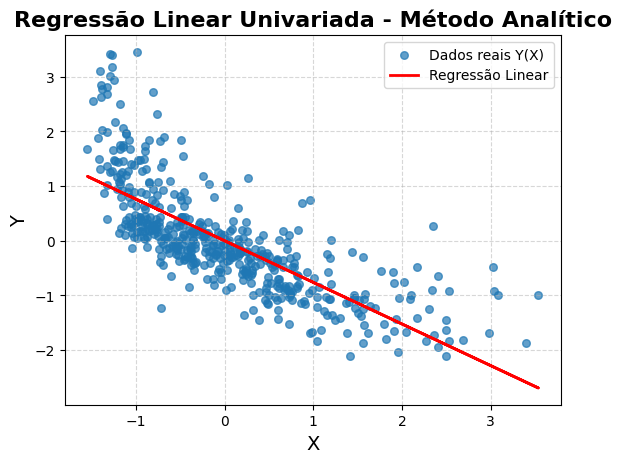

In [ ]:
# Visualização gráfica da regressão linear univariada pelo método analítico.

plt.scatter(X_true, y_true, label = "Dados reais Y(X)", s=30, alpha=0.7)
plt.plot(X_true, y_predict, color='red', label = "Regressão Linear", linewidth=2)
plt.title("Regressão Linear Univariada - Método Analítico", fontsize=16, fontweight='bold')
plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()